# Think token 上限 × 蒸馏步数:对 t_think / t_image 比值的影响

**问题**:在模拟步数蒸馏(减少去噪步数、关闭 CFG)的前提下,人为限制 `<think>` 规划文本的
token 数上限(硬截断 `max_length`),`t_think` 与 `t_image` 的比值如何变化?

**设计**(2026-07-02 定稿):
- 网格:`num_timesteps ∈ {5, 10, 50}` × `max_think_token_n ∈ {32, 64, 128, 256, 1000}`,完全交叉 15 个 condition
- CFG 全关(`cfg_text_scale=1.0`),与上一轮 `think_bottleneck_benchmark.ipynb` 的 Block A 一致,
  其中 N=50 档可与旧数据(t_image≈26.6s)直接对照
- 贪心解码(`do_sample=False`)不变:自变量是 cap 这个旋钮,不引入采样随机性
- 每来源 8 条 prompt(GenEval + WISE 各 8,共 16)× 2 repeats = **480 trials,预计 ~2.5-3h**
- 主指标:`ratio = t_think / t_image` 与 `fraction_think = t_think / (t_think + t_image)` 都记录
- 诊断字段:`hit_cap`(是否被上限硬截断)、`think_closed`(`</think>` 是否正常闭合)

**背景校准**(来自上一轮实验):贪心解码下两来源的自然 think 长度均值 ≈160 token
(geneval 极稳定,wise 约 ±19 token)。因此预期 cap=32/64/128 三档必然触发截断,
cap=256/1000 大概率不触发(结果应几乎相同)——`hit_cap` 字段就是用来核实这一点的。

## 1. 环境 / import

In [1]:
import os
import sys
import json
import time
import random
import gc
from copy import deepcopy
from contextlib import contextmanager

# ── 缓解 CUDA 显存碎片化（错误信息中建议的设置）──
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ── 路径修正: 把项目根目录加入 sys.path ──
_proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(_proj_root, "data")):
    if _proj_root not in sys.path:
        sys.path.insert(0, _proj_root)
    os.chdir(_proj_root)
else:
    raise RuntimeError(f"找不到项目根目录(data/ 目录) from {os.getcwd()}")
print(f"workdir: {os.getcwd()}")

import numpy as np
import torch

try:
    import pandas as pd
except ImportError:
    os.system(f"{sys.executable} -m pip install pandas")
    import pandas as pd

try:
    from scipy.stats import wilcoxon
except ImportError:
    os.system(f"{sys.executable} -m pip install scipy")
    from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

from safetensors.torch import load_file
from data.data_utils import add_special_tokens
from data.transforms import ImageTransform
from modeling.bagel import (
    BagelConfig, Bagel, Qwen2Config, Qwen2ForCausalLM, SiglipVisionConfig, SiglipVisionModel
)
from modeling.qwen2 import Qwen2Tokenizer
from modeling.autoencoder import load_ae
from inferencer import InterleaveInferencer, GEN_THINK_SYSTEM_PROMPT

assert torch.cuda.is_available(), "This benchmark needs a CUDA GPU."
print("torch:", torch.__version__)
print("device:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))
try:
    import flash_attn
    print("flash_attn:", flash_attn.__version__)
except ImportError:
    print("flash_attn: not installed")

workdir: /home/wuwenxuan03/bagel
torch: 2.5.1+cu121
device: NVIDIA GeForce RTX 4090
capability: (8, 9)
flash_attn: 2.5.8


## 2. 模型加载(accelerate 多卡 device_map)

与 `think_bottleneck_benchmark.ipynb` 相同的加载方式。`MODEL_PATH` 按实际机器路径修改。

In [ ]:
MODEL_PATH = "/home/wuwenxuan03/bagel/BAGEL-7B-MoT"
DEVICE = "cuda:0"  # inferencer 仍以 cuda:0 为主设备,accelerate 会自动管理跨卡 forward

# ── 多卡策略 ──
# 本机 8×4090 全为 SYS(PCIe)互联, 没有 P2P/NVLink。
# 跨卡 forward 每跳都经 CPU 中转, 所以 accelerate 用的 GPU 越少越快。
# 2 卡足以装下 bf16 模型 (2×22 GiB = 44 GiB > ~28 GB 权重)。
# 其余 6 卡留给 §8b 多进程并行 sweep。
N_ACCELERATE_GPUS = 2  # 调大不加速, 反而增加 PCIe 往返开销
# ─────────────────

from accelerate import infer_auto_device_map, load_checkpoint_and_dispatch, init_empty_weights

llm_config = Qwen2Config.from_json_file(os.path.join(MODEL_PATH, "llm_config.json"))
llm_config.qk_norm = True
llm_config.tie_word_embeddings = False
llm_config.layer_module = "Qwen2MoTDecoderLayer"

vit_config = SiglipVisionConfig.from_json_file(os.path.join(MODEL_PATH, "vit_config.json"))
vit_config.rope = False
vit_config.num_hidden_layers = vit_config.num_hidden_layers - 1

vae_model, vae_config = load_ae(local_path=os.path.join(MODEL_PATH, "ae.safetensors"))

config = BagelConfig(
    visual_gen=True,
    visual_und=True,
    llm_config=llm_config,
    vit_config=vit_config,
    vae_config=vae_config,
    vit_max_num_patch_per_side=70,
    connector_act="gelu_pytorch_tanh",
    latent_patch_size=2,
    max_latent_size=64,
)

with init_empty_weights():
    language_model = Qwen2ForCausalLM(llm_config)
    vit_model = SiglipVisionModel(vit_config)
    model = Bagel(language_model, vit_model, config)
    model.vit_model.vision_model.embeddings.convert_conv2d_to_linear(vit_config, meta=True)

tokenizer = Qwen2Tokenizer.from_pretrained(MODEL_PATH)
tokenizer, new_token_ids, _ = add_special_tokens(tokenizer)

# ── accelerate device_map: 仅用前 N_ACCELERATE_GPUS 张卡 ──
max_mem_per_gpu = "22GiB"
device_map = infer_auto_device_map(
    model,
    max_memory={i: max_mem_per_gpu for i in range(N_ACCELERATE_GPUS)},
    no_split_module_classes=["Bagel", "Qwen2MoTDecoderLayer"],
)
print("device_map:", device_map)

same_device_modules = [
    "language_model.model.embed_tokens", "time_embedder", "latent_pos_embed",
    "vae2llm", "llm2vae", "connector", "vit_pos_embed",
]
first_device = device_map.get(same_device_modules[0])
for k in same_device_modules:
    device_map[k] = first_device if k in device_map else "cuda:0"

model = load_checkpoint_and_dispatch(
    model,
    checkpoint=os.path.join(MODEL_PATH, "ema.safetensors"),
    device_map=device_map,
    offload_buffers=True,
    dtype=torch.bfloat16,
    force_hooks=True,
    offload_folder="/tmp/offload",
)
model = model.eval()

vae_model = vae_model.to(DEVICE).eval()

vae_transform = ImageTransform(1024, 512, 16)
vit_transform = ImageTransform(980, 224, 14)

print(f"Model loaded with accelerate device_map ({N_ACCELERATE_GPUS} GPU(s)), inferencer on {DEVICE}")

## 3. `InterleaveInferencer` + 工具函数

`reset_taylorseer_state`:本实验虽然不开 TaylorSeer,但保留每 trial 前后强制复位,
防御 `qwen2_navit.py` 中 per-layer `enable_taylorseer` 只置 True 不复位的状态泄漏
(如果这个进程之前跑过 TaylorSeer 实验)。

In [ ]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def reset_taylorseer_state(model):
    lm = model.language_model.model
    lm.enable_taylorseer = False
    for attr in ("cache_dic", "current"):
        if hasattr(lm, attr):
            delattr(lm, attr)
    for layer in lm.layers:
        layer.enable_taylorseer = False
        for attr in ("cache_dic", "current"):
            if hasattr(layer, attr):
                delattr(layer, attr)
    torch.cuda.synchronize()
    torch.cuda.empty_cache()


class _Elapsed:
    elapsed = None


@contextmanager
def sync_timer():
    torch.cuda.synchronize()
    result = _Elapsed()
    t0 = time.perf_counter()
    yield result
    torch.cuda.synchronize()
    result.elapsed = time.perf_counter() - t0


inferencer = InterleaveInferencer(
    model=model,
    vae_model=vae_model,
    tokenizer=tokenizer,
    vae_transform=vae_transform,
    vit_transform=vit_transform,
    new_token_ids=new_token_ids,
)

# sanity check: tokenizer(text, add_special_tokens=False) must return a plain token-id list
_sanity = tokenizer("hello world", add_special_tokens=False)
print("tokenizer sanity check -> input_ids:", _sanity.input_ids, "(should be a short list of ints)")


## 4. Prompt 采样

`PROMPT_SEED=0` 与上一轮一致,`random.Random(0).sample` 是确定性的,因此每来源的
**前 3 条与上一轮完全相同**(可对照),后 5 条是新增样本。

In [ ]:
GENEVAL_PROMPTS_PATH = "eval/gen/geneval/prompts/evaluation_metadata.jsonl"
WISE_PROMPTS_PATH = "eval/gen/wise/final_data.json"

PROMPT_SEED = 0
N_PROMPTS_PER_SOURCE = 8

with open(GENEVAL_PROMPTS_PATH, "r", encoding="utf-8") as f:
    geneval_prompts_all = [json.loads(line)["prompt"] for line in f]

with open(WISE_PROMPTS_PATH, "r", encoding="utf-8") as f:
    wise_prompts_all = [d["Prompt"] for d in json.load(f)]

_rng = random.Random(PROMPT_SEED)
sampled_geneval = _rng.sample(geneval_prompts_all, N_PROMPTS_PER_SOURCE)
sampled_wise = _rng.sample(wise_prompts_all, N_PROMPTS_PER_SOURCE)

# 稳定的 prompt_id(不用 Python 内置 hash(),它受 PYTHONHASHSEED 影响跨进程不稳定)
sampled_prompts = (
    [dict(source="geneval", prompt=p, prompt_id=i) for i, p in enumerate(sampled_geneval)]
    + [dict(source="wise", prompt=p, prompt_id=i + N_PROMPTS_PER_SOURCE) for i, p in enumerate(sampled_wise)]
)

for p in sampled_prompts:
    print(f"[{p['source']}][id={p['prompt_id']}] {p['prompt'][:80]}")


## 5. `run_trial`:单次运行函数

与上一轮的区别:
1. `max_think_token_n` 从全局常量变成 condition 字段,作为 `gen_text(max_length=...)` 传入;
2. 新增 `hit_cap`:生成 token 数逼近上限(≥ cap-2,留出 start/eos token 的计数余量)即视为被硬截断;
3. 新增 `think_closed`:生成文本是否以 `</think>` 正常收尾。二者合起来能区分
   "模型自己写完了" vs "被掐断在半句话上"。

注意:被截断的 think 没有 `</think>` 闭合,仍会被原样 `update_context_text` 进 KV cache
条件化图像生成——这正是"硬截断"方案要测的真实行为,不做修补。

In [ ]:
IMAGE_SHAPE = (1024, 1024)


def run_trial(prompt, cond, seed, return_image=False):
    """cond: dict with keys num_timesteps, max_think_token_n, cfg_text_scale, cfg_img_scale,
    cfg_interval, cfg_renorm_min, cfg_renorm_type, timestep_shift, enable_taylorseer."""
    reset_taylorseer_state(model)
    set_all_seeds(seed)

    record = dict(prompt=prompt, seed=seed, **cond)
    img = None
    gen_context = cfg_text_context = cfg_img_context = None
    try:
        gen_context = inferencer.init_gen_context()
        cfg_text_context = deepcopy(gen_context)
        cfg_img_context = deepcopy(gen_context)

        with torch.autocast(device_type="cuda", enabled=True, dtype=torch.bfloat16):
            with sync_timer() as t_prefill:
                gen_context = inferencer.update_context_text(GEN_THINK_SYSTEM_PROMPT, gen_context)
                cfg_img_context = inferencer.update_context_text(GEN_THINK_SYSTEM_PROMPT, cfg_img_context)
                cfg_text_context = deepcopy(gen_context)
                gen_context = inferencer.update_context_text(prompt, gen_context)
                cfg_img_context = inferencer.update_context_text(prompt, cfg_img_context)

            with sync_timer() as t_think:
                gen_text = inferencer.gen_text(
                    gen_context, do_sample=False, temperature=0.3,
                    max_length=cond["max_think_token_n"],
                )

            gen_context = inferencer.update_context_text(gen_text, gen_context)

            with sync_timer() as t_image:
                img = inferencer.gen_image(
                    IMAGE_SHAPE,
                    gen_context,
                    cfg_text_precontext=cfg_text_context,
                    cfg_img_precontext=cfg_img_context,
                    cfg_text_scale=cond["cfg_text_scale"],
                    cfg_img_scale=cond["cfg_img_scale"],
                    cfg_interval=cond["cfg_interval"],
                    cfg_renorm_min=cond["cfg_renorm_min"],
                    cfg_renorm_type=cond["cfg_renorm_type"],
                    timestep_shift=cond["timestep_shift"],
                    num_timesteps=cond["num_timesteps"],
                    enable_taylorseer=cond["enable_taylorseer"],
                )

        think_token_count = len(tokenizer(gen_text, add_special_tokens=False).input_ids)
        # generate_text 的 max_length 计数包含 start token(截断时无 eos),
        # 解码后剥掉特殊 token,内容 token 数 ≈ cap-1;自然结束时 ≈ 步数-2。
        # 用 cap-2 作阈值,配合 think_closed 区分两种结束方式。
        hit_cap = think_token_count >= cond["max_think_token_n"] - 2
        think_closed = gen_text.strip().endswith("</think>")

        record.update(
            t_prefill=t_prefill.elapsed,
            t_think=t_think.elapsed,
            t_image=t_image.elapsed,
            think_token_count=think_token_count,
            hit_cap=hit_cap,
            think_closed=think_closed,
            gen_text=gen_text,
            ok=True,
            error=None,
        )
    except Exception as e:
        record.update(
            t_prefill=None, t_think=None, t_image=None,
            think_token_count=None, hit_cap=None, think_closed=None,
            gen_text=None, ok=False, error=repr(e),
        )
    finally:
        # 显式释放 KV cache 引用,帮助 Python GC 在下一轮 allocation 前回收显存
        del gen_context, cfg_text_context, cfg_img_context
        reset_taylorseer_state(model)
        gc.collect()
        torch.cuda.empty_cache()

    if return_image:
        record["image"] = img
    return record

## 6. Condition 网格(3 × 5 完全交叉)

CFG 全关、TaylorSeer 全关,唯一变化的是 `num_timesteps` 和 `max_think_token_n` 两个自变量。

In [8]:
NUM_TIMESTEPS_LIST = [50, 10, 5]
MAX_THINK_TOKEN_LIST = [1000, 256, 128, 64, 32]

ALL_CONDITIONS = [
    dict(
        num_timesteps=n, max_think_token_n=cap,
        cfg_text_scale=1.0, cfg_img_scale=1.0,
        cfg_interval=[0.4, 1.0], cfg_renorm_min=0.0, cfg_renorm_type="global",
        timestep_shift=3.0, enable_taylorseer=False,
    )
    for n in NUM_TIMESTEPS_LIST
    for cap in MAX_THINK_TOKEN_LIST
]
print(f"{len(ALL_CONDITIONS)} conditions "
      f"({len(NUM_TIMESTEPS_LIST)} num_timesteps x {len(MAX_THINK_TOKEN_LIST)} caps)")


15 conditions (3 num_timesteps x 5 caps)


## 7. Warm-up(丢弃结果,吸收一次性 CUDA/kernel 编译开销)

In [ ]:
_warmup_prompt = sampled_prompts[0]["prompt"]
_warmup_cond = ALL_CONDITIONS[0]  # N=50, cap=1000

_ = run_trial(_warmup_prompt, _warmup_cond, seed=999)
if not _["ok"]:
    print("warm-up FAILED:", _["error"])
else:
    print("warm-up (N=50, cap=1000):  t_think=%.3fs  t_image=%.3fs  tokens=%d  hit_cap=%s"
          % (_["t_think"], _["t_image"], _["think_token_count"], _["hit_cap"]))


## 8a. 单进程 sweep（调试/小规模用）

16 prompt × 15 condition × 2 repeat = 480 trial,乱序执行以避免热漂移与条件顺序混淆,
每 20 条落盘一次 checkpoint。

> **注意**: 这个 cell 只用当前 notebook 加载的 2 卡模型,预计 ~3h。
> 跑完整 480 trial 请用下面 §8b 的多卡并行模式 (~20min)。

In [ ]:
N_REPEATS = 2
SWEEP_SHUFFLE_SEED = 42
SEED_BASE = 1000

OUTPUT_DIR = "experiments/think_cap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

trials = [
    (p["prompt"], p["source"], p["prompt_id"], cond, repeat)
    for p in sampled_prompts
    for cond in ALL_CONDITIONS
    for repeat in range(N_REPEATS)
]

_shuffle_rng = random.Random(SWEEP_SHUFFLE_SEED)
_shuffle_rng.shuffle(trials)

print(f"Total trials: {len(trials)}")


In [ ]:
rows = []
for i, (prompt, source, prompt_id, cond, repeat) in enumerate(trials):
    seed = SEED_BASE + prompt_id * 1000 + repeat  # 稳定可复现,不依赖 Python 内置 hash()
    row = run_trial(prompt, cond, seed=seed)
    row["source"] = source
    row["prompt_id"] = prompt_id
    row["repeat"] = repeat
    rows.append(row)

    if not row["ok"]:
        print(f"[{i + 1}/{len(trials)}] FAILED: {row['error']}")

    if (i + 1) % 20 == 0 or (i + 1) == len(trials):
        pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_DIR, "trials_partial.csv"), index=False)
        n_ok = sum(r["ok"] for r in rows)
        n_fail = (i + 1) - n_ok
        print(f"[{i + 1}/{len(trials)}] checkpointed ({n_ok} ok, {n_fail} failed so far)")
        # 每 20 trial 额外做一次深度清理,防御 Python GC 滞后导致的碎片化
        gc.collect()
        torch.cuda.empty_cache()

## 8b. 多卡并行 sweep（推荐，利用全部 8 卡）

使用 `experiments/run_cap_sweep_mp.py`，每张 GPU 独立加载模型、并行跑不同的 trial。

| 模式 | 总耗时 | 用法 |
|------|--------|------|
| 8×单卡 | ~20min | 模型能装入 24GB 单卡时最快 |
| 4×双卡 | ~40min | 保守方案，显存压力更小 |

运行时可在终端 `tail -f experiments/think_cap_outputs/worker_*.csv` 查看进度。

In [2]:
import subprocess, sys, glob

# OUTPUT_DIR 必须与 run_cap_sweep_mp.py 中的一致
OUTPUT_DIR = "experiments/think_cap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 模型 ~28GB, 单卡 24GB 装不下, 必须 2 卡一组
# 8 卡 ÷ 2 = 4 个并行 worker, 预计 ~40min
SWEEP_GPUS_PER_WORKER = 2

print(f"启动多卡并行 sweep (每 worker {SWEEP_GPUS_PER_WORKER} GPU)...")
result = subprocess.run(
    [sys.executable, "experiments/run_cap_sweep_mp.py",
     "--gpus", "0,1,2,3,4,5,6,7",
     "--gpus-per-worker", str(SWEEP_GPUS_PER_WORKER)],
    cwd=os.getcwd(),
    capture_output=False,  # 实时输出进度
)

if result.returncode == 0:
    print("\n多卡 sweep 完成！加载合并结果到 df:")
    merged_path = os.path.join(OUTPUT_DIR, "trials.csv")
    if os.path.exists(merged_path):
        df = pd.read_csv(merged_path)
        print(f"Loaded {len(df)} rows from {merged_path}")
        print(f"OK: {df['ok'].sum()}, Failed: {(~df['ok']).sum()}")
        print("df 已就绪，继续跑 §9-13 分析")
    else:
        print(f"WARNING: {merged_path} 不存在, 检查 worker 输出")
else:
    print(f"\n多卡 sweep 失败 (exit code {result.returncode})")
    print("请检查终端输出，或回退到 §8a 单进程 sweep")

启动多卡并行 sweep (每 worker 2 GPU)...
Total trials: 480
Workers: 4 (each using 2 GPU(s))
  Worker 0: GPU(s) [0, 1]
  Worker 1: GPU(s) [2, 3]
  Worker 2: GPU(s) [4, 5]
  Worker 3: GPU(s) [6, 7]
Trials per worker: ~120
Estimated time: ~0.6h

[Main] Spawned worker 0 (PID 55776) on GPU(s) 0,1
[Main] Spawned worker 1 (PID 55777) on GPU(s) 2,3
[Main] Spawned worker 2 (PID 55778) on GPU(s) 4,5
[Main] Spawned worker 3 (PID 55779) on GPU(s) 6,7
[Worker 0] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 0] Trials: 120
[Worker 0] Loading with accelerate device_map (2 GPUs)...
[Worker 1] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 1] Trials: 120
[Worker 1] Loading with accelerate device_map (2 GPUs)...
[Worker 2] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 2] Trials: 120
[Worker 2] Loading with accelerate device_map (2 GPUs)...
[Worker 3] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 3] Trials: 120
[Worker 3] Loading with accelerate device_map (2 GPUs)...
[Worker 2] device_map: GPU 0 

The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Ple

[Worker 0] Warm-up...


We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.
We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.
We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.


[Worker 2] Warm-up...
[Worker 1] Warm-up...
[Worker 3] Warm-up...


...

[Worker 2] [120/120] ok=120/120, elapsed=2154s, ETA=0s
[Worker 2] DONE: 120/120 ok in 2154s → /home/wuwenxuan03/bagel/experiments/think_cap_outputs/worker_2.csv


  0%|          | 0/49 [00:00<?, ?it/s]

[Worker 1] [120/120] ok=120/120, elapsed=2156s, ETA=0s
[Worker 1] DONE: 120/120 ok in 2156s → /home/wuwenxuan03/bagel/experiments/think_cap_outputs/worker_1.csv


100%|██████████| 9/9 [00:04<00:00,  1.88it/s]


[Worker 0] [120/120] ok=120/120, elapsed=2253s, ETA=0s
[Worker 0] DONE: 120/120 ok in 2254s → /home/wuwenxuan03/bagel/experiments/think_cap_outputs/worker_0.csv
[Main] Worker 0 DONE
[Main] Worker 1 DONE
[Main] Worker 2 DONE
[Main] Worker 3 DONE

Merged 480 rows (480 ok) → /home/wuwenxuan03/bagel/experiments/think_cap_outputs/trials.csv

多卡 sweep 完成！加载合并结果到 df:
Loaded 480 rows from experiments/think_cap_outputs/trials.csv
OK: 480, Failed: 0
df 已就绪，继续跑 §9-13 分析


## 9. 保存原始结果表

In [3]:
df = pd.DataFrame(rows)
df["hardware"] = torch.cuda.get_device_name(0)
df["timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
df.to_csv(os.path.join(OUTPUT_DIR, "trials.csv"), index=False)
print(f"Saved {len(df)} rows ({df['ok'].sum()} ok, {(~df['ok']).sum()} failed) to {OUTPUT_DIR}/trials.csv")
df.head()


NameError: name 'rows' is not defined

## 10. 聚合与派生指标

两个主指标都算:`ratio_think_image = t_think / t_image`(字面比值,截断+少步数时可远大于 1)
和 `fraction_think = t_think / (t_think + t_image)`(占比,0~1)。

In [4]:
ok = df[df["ok"]].copy()
ok["ratio_think_image"] = ok["t_think"] / ok["t_image"]
ok["fraction_think"] = ok["t_think"] / (ok["t_think"] + ok["t_image"])

agg = (
    ok.groupby(["num_timesteps", "max_think_token_n", "source"])
    .agg(
        t_think_mean=("t_think", "mean"), t_think_std=("t_think", "std"),
        t_image_mean=("t_image", "mean"), t_image_std=("t_image", "std"),
        ratio_mean=("ratio_think_image", "mean"), ratio_std=("ratio_think_image", "std"),
        fraction_think_mean=("fraction_think", "mean"), fraction_think_std=("fraction_think", "std"),
        think_token_count_mean=("think_token_count", "mean"),
        hit_cap_rate=("hit_cap", "mean"),
        think_closed_rate=("think_closed", "mean"),
        n=("t_think", "count"),
    )
    .reset_index()
    .sort_values(["num_timesteps", "max_think_token_n", "source"])
)
agg.to_csv(os.path.join(OUTPUT_DIR, "aggregated.csv"), index=False)
agg


,num_timesteps,max_think_token_n,source,t_think_mean,t_think_std,t_image_mean,t_image_std,ratio_mean,ratio_std,fraction_think_mean,fraction_think_std,think_token_count_mean,hit_cap_rate,think_closed_rate,n
0,5,32,geneval,1.740551,0.011639,2.426227,0.028182,0.717456,0.007373,0.417733,0.002505,31.000,1.0,0.0,16
1,5,32,wise,1.750219,0.021752,2.430788,0.021514,0.720039,0.008198,0.418606,0.002776,31.000,1.0,0.0,16
2,5,64,geneval,3.501945,0.029577,2.433697,0.020055,1.438971,0.009938,0.589985,0.001664,63.000,1.0,0.0,16
3,5,64,wise,3.493083,0.031835,2.434290,0.025344,1.435033,0.014353,0.589315,0.002411,63.000,1.0,0.0,16
4,5,128,geneval,6.994043,0.063886,2.446127,0.029087,2.859487,0.033002,0.740880,0.002218,127.000,1.0,0.0,16
5,5,128,wise,6.990375,0.074528,2.435315,0.022087,2.870469,0.023741,0.741624,0.001582,127.000,1.0,0.0,16
6,5,256,geneval,9.021258,0.721931,2.437071,0.025362,3.702011,0.297715,0.786499,0.013977,164.125,0.0,1.0,16
7,5,256,wise,8.811481,0.860319,2.434189,0.024015,3.620845,0.362076,0.782268,0.018040,160.375,0.0,1.0,16
8,5,1000,geneval,9.030682,0.688848,2.438835,0.024799,3.702778,0.277825,0.786637,0.013099,164.125,0.0,1.0,16
9,5,1000,wise,8.812918,0.885675,2.435443,0.029371,3.617679,0.352599,0.782189,0.017539,160.375,0.0,1.0,16


## 11. 画图

图 1:`ratio = t_think / t_image` 随 cap 变化,每个 `num_timesteps` 一条线(y 取 log);
图 2:`fraction_think` 同布局;图 3:实际生成 token 数随 cap 的饱和曲线 + `hit_cap` 命中率。

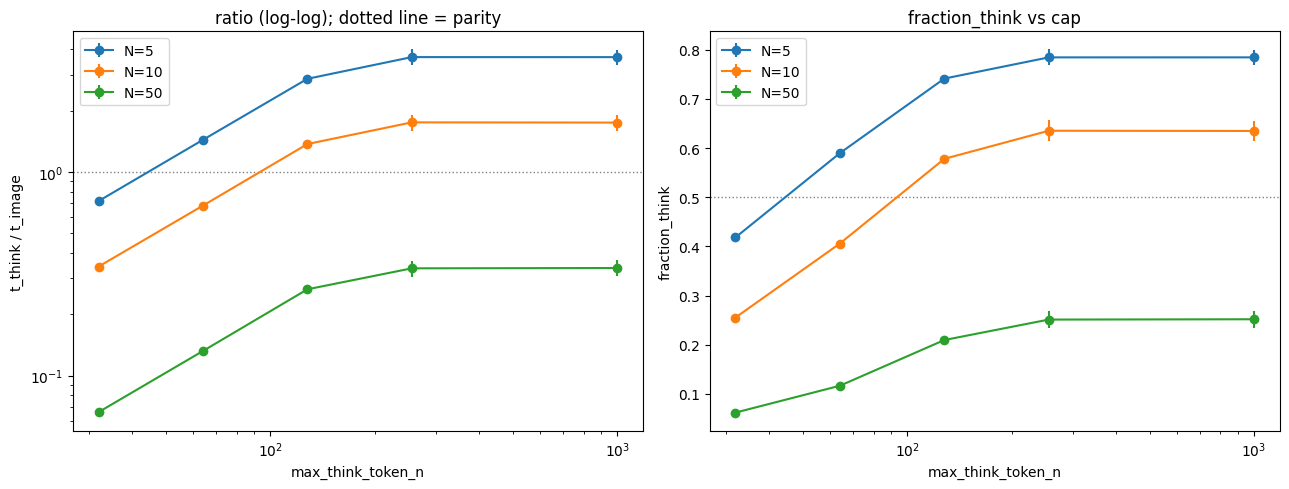

In [5]:
pooled = (
    ok.groupby(["num_timesteps", "max_think_token_n"])
    .agg(ratio_mean=("ratio_think_image", "mean"), ratio_std=("ratio_think_image", "std"),
         fraction_mean=("fraction_think", "mean"), fraction_std=("fraction_think", "std"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for n in sorted(pooled["num_timesteps"].unique()):
    sub = pooled[pooled["num_timesteps"] == n].sort_values("max_think_token_n")
    axes[0].errorbar(sub["max_think_token_n"], sub["ratio_mean"], yerr=sub["ratio_std"],
                     marker="o", label=f"N={n}")
    axes[1].errorbar(sub["max_think_token_n"], sub["fraction_mean"], yerr=sub["fraction_std"],
                     marker="o", label=f"N={n}")

axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].axhline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].set_xlabel("max_think_token_n"); axes[0].set_ylabel("t_think / t_image")
axes[0].set_title("ratio (log-log); dotted line = parity"); axes[0].legend()

axes[1].set_xscale("log")
axes[1].axhline(0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("max_think_token_n"); axes[1].set_ylabel("fraction_think")
axes[1].set_title("fraction_think vs cap"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ratio_vs_cap.png"), dpi=150)
plt.show()


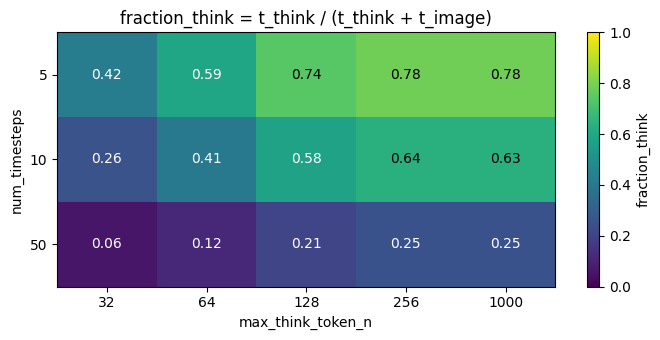

In [6]:
# 热力图:3x5 网格的 fraction_think 均值一览
pivot = pooled.pivot(index="num_timesteps", columns="max_think_token_n", values="fraction_mean")
pivot = pivot.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel("max_think_token_n"); ax.set_ylabel("num_timesteps")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center",
                color="white" if pivot.values[i, j] < 0.6 else "black")
fig.colorbar(im, label="fraction_think")
plt.title("fraction_think = t_think / (t_think + t_image)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fraction_think_heatmap.png"), dpi=150)
plt.show()


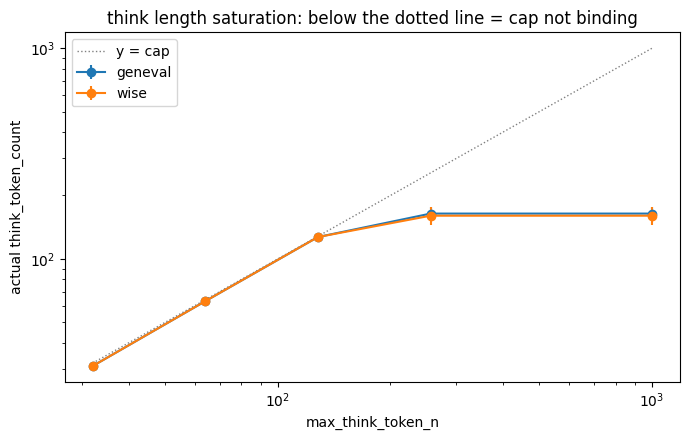

hit_cap rate (被硬截断的比例) / think_closed rate (</think> 正常闭合比例):
 max_think_token_n  source  hit_cap_rate  think_closed_rate  n
                32 geneval           1.0                0.0 48
                32    wise           1.0                0.0 48
                64 geneval           1.0                0.0 48
                64    wise           1.0                0.0 48
               128 geneval           1.0                0.0 48
               128    wise           1.0                0.0 48
               256 geneval           0.0                1.0 48
               256    wise           0.0                1.0 48
              1000 geneval           0.0                1.0 48
              1000    wise           0.0                1.0 48


In [9]:
# 饱和曲线:实际生成 token 数 vs cap;并打印 hit_cap / think_closed 命中率
fig, ax = plt.subplots(figsize=(7, 4.5))
for source in sorted(ok["source"].unique()):
    sub = (
        ok[ok["source"] == source]
        .groupby("max_think_token_n")["think_token_count"]
        .agg(["mean", "std"]).reset_index().sort_values("max_think_token_n")
    )
    ax.errorbar(sub["max_think_token_n"], sub["mean"], yerr=sub["std"], marker="o", label=source)
lims = [min(MAX_THINK_TOKEN_LIST), max(MAX_THINK_TOKEN_LIST)]
ax.plot(lims, lims, color="gray", linestyle=":", linewidth=1, label="y = cap")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("max_think_token_n"); ax.set_ylabel("actual think_token_count")
ax.set_title("think length saturation: below the dotted line = cap not binding")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "token_saturation.png"), dpi=150)
plt.show()

print("hit_cap rate (被硬截断的比例) / think_closed rate (</think> 正常闭合比例):")
diag = (
    ok.groupby(["max_think_token_n", "source"])
    .agg(hit_cap_rate=("hit_cap", "mean"), think_closed_rate=("think_closed", "mean"), n=("ok", "count"))
    .reset_index()
)
print(diag.to_string(index=False))


## 12. 统计检验

对每个 `num_timesteps` 档:以 prompt 为配对单位(16 对),比较 cap=32 与 cap=1000 的
`fraction_think`,Wilcoxon 符号秩检验。

In [10]:
CAP_LOW, CAP_HIGH = min(MAX_THINK_TOKEN_LIST), max(MAX_THINK_TOKEN_LIST)

for n in sorted(ok["num_timesteps"].unique()):
    sub = ok[ok["num_timesteps"] == n]
    low = sub[sub["max_think_token_n"] == CAP_LOW].groupby("prompt")["fraction_think"].mean()
    high = sub[sub["max_think_token_n"] == CAP_HIGH].groupby("prompt")["fraction_think"].mean()
    common = low.index.intersection(high.index)
    if len(common) >= 6:
        stat, p_value = wilcoxon(low.loc[common], high.loc[common])
        print(f"N={n:>3}: cap={CAP_LOW} vs cap={CAP_HIGH}, paired prompts={len(common)}, "
              f"Wilcoxon statistic={stat:.4f}, p={p_value:.6f}")
    else:
        print(f"N={n:>3}: 配对 prompt 不足({len(common)}),跳过检验")


N=  5: cap=32 vs cap=1000, paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031
N= 10: cap=32 vs cap=1000, paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031
N= 50: cap=32 vs cap=1000, paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031


**局限性**:

1. 硬截断的 think 没有 `</think>` 闭合、可能停在半句话上,它衡量的是"强行掐断思考"的
   延迟收益;图像质量的损失不代表"模型自然短思考"(prompt 引导)的质量,二者是不同的干预。
2. 无真实步数蒸馏权重——`num_timesteps`/CFG 的调整只是计算量代理,N=5/10 的出图质量
   不代表真实蒸馏模型。
3. 多卡 accelerate device_map 环境:`t_think` 混入逐 token 的跨卡通信开销,绝对数值
   (尤其 think 侧)相对单卡大显存部署偏高;组间对比(同一硬件)仍公平。
4. cap=256 与 cap=1000 若结果几乎相同,说明二者都未触发截断(用 `hit_cap` 核实),
   等价于两份"不截断"对照,属预期内。

## 13.(可选,默认跳过)`torch.profiler` 补充诊断

In [ ]:
RUN_PROFILER = False

if RUN_PROFILER:
    from torch.profiler import profile, ProfilerActivity

    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=False) as prof:
        run_trial(sampled_prompts[0]["prompt"], ALL_CONDITIONS[0], seed=SEED_BASE)
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))
